# Forward-Risk-Manager: Intensive Colab T4 Runbook

This notebook runs the full GPU-heavy workflow end-to-end:
1. Environment and GPU checks
2. Drive mount and repo sync
3. Dependency install + editable package install + tests
4. Build/train/benchmark/sweep (+ optional sweep promotion + retrain)
5. Goodness backtest + constrained scenarios + stress test
6. Hallucination calibration + diagnostics
7. Artifact bundle export and download


## 1) Runtime Setup

In Colab:
- Runtime -> Change runtime type -> Hardware accelerator: `GPU`
- Prefer `T4` and high-RAM runtime when available


In [10]:
import os
import subprocess
import sys

# CUDA/runtime friendliness
os.environ.setdefault('PYTHONUNBUFFERED', '1')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
os.environ.setdefault('PYTORCH_ALLOC_CONF', 'max_split_size_mb:256')

print('python:', sys.version)

try:
    import torch
except Exception as exc:
    raise RuntimeError('PyTorch is required in Colab runtime.') from exc

print('torch:', torch.__version__)
print('cuda_available:', torch.cuda.is_available())
print('cuda_version:', torch.version.cuda)

try:
    print(subprocess.check_output(['nvidia-smi', '-L'], text=True))
except Exception as exc:
    print('nvidia-smi unavailable:', exc)

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is not available. Enable GPU runtime and rerun.')

gpu_name = torch.cuda.get_device_name(0)
print('gpu:', gpu_name)
if 'T4' not in gpu_name.upper():
    print('WARNING: GPU is not T4. Notebook still works; timings will differ.')

# Throughput-friendly settings for T4
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True


python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
torch: 2.9.0+cu128
cuda_available: True
cuda_version: 12.8
GPU 0: Tesla T4 (UUID: GPU-5b3073d5-374a-6c74-5649-cb6bad902c0d)

gpu: Tesla T4


## 2) Mount Drive And Open Repo


In [11]:
from pathlib import Path
import os
import subprocess

from google.colab import drive

drive.mount('/content/drive', force_remount=False)

REPO_DIR = '/content/drive/MyDrive/Forward-Risk-Manager'
if not Path(REPO_DIR).exists():
    raise FileNotFoundError(f'Repo not found: {REPO_DIR}')

%cd $REPO_DIR
print('cwd:', os.getcwd())

if Path('.git').exists():
    print(subprocess.check_output(['git', 'status', '--short'], text=True)[:4000])
else:
    print('No .git directory found. Running from copied folder is fine.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Forward-Risk-Manager
cwd: /content/drive/MyDrive/Forward-Risk-Manager
D  .gitignore
D  README.md
D  configs/baseline.toml
D  configs/default.toml
D  configs/long_alltickers.toml
D  configs/long_constituents.toml
D  configs/train_long_alltickers.toml
D  configs/train_long_constituents.toml
D  notebooks/colab_setup.ipynb
D  pyproject.toml
D  reports/index.csv
D  reports/published/benchmark/latest.csv
D  reports/published/benchmark/latest_bar.png
D  reports/published/benchmark/latest_speed_sep.png
D  reports/published/hallucination/calibration_by_ticker_latest.csv
D  reports/published/hallucination/calibration_latest.json
D  reports/published/hallucination/diagnostics_latest.png
D  reports/published/hallucination/plot_latest.png
D  reports/published/scenario/constraints_latest.csv
D  reports/published/scenario/latest.csv
D  reports/publish

## 3) Install Dependencies And Verify Tests


In [12]:
import shlex
import subprocess
import sys

PYTHON = shlex.quote(sys.executable)

commands = [
    f"{PYTHON} -m pip install --upgrade pip",
    f"{PYTHON} -m pip install -r requirements.txt",
    f"{PYTHON} -m pip install pytest",
    # --no-build-isolation avoids unnecessary build-dep fetches in constrained environments
    f"{PYTHON} -m pip install -e . --no-build-isolation",
    f"{PYTHON} -m pytest -q",
]

for cmd in commands:
    print('+', cmd)
    subprocess.run(cmd, shell=True, check=True)

print('Dependency + test setup complete.')


+ /usr/bin/python3 -m pip install --upgrade pip
+ /usr/bin/python3 -m pip install -r requirements.txt
+ /usr/bin/python3 -m pip install pytest
+ /usr/bin/python3 -m pip install -e . --no-build-isolation
+ /usr/bin/python3 -m pytest -q
Dependency + test setup complete.


## 4) Intensive Session Controls


In [13]:
from pathlib import Path
import tomllib

# Base configs
BUILD_CONFIG = 'configs/long_constituents.toml'
TRAIN_CONFIG = 'configs/train_long_constituents.toml'
SWEEP_SECTION = 'sweep'
SWEEP_E2E_SECTION = 'sweep_e2e'
DEVICE = 'cuda'

# Run layout
RUN_ID = 'long_constituents'
RUN_ROOT = f'runs/experiments/{RUN_ID}'
PUBLISHED_ROOT = 'reports/published'
REPORT_INDEX_CSV = 'reports/index.csv'
RUNTIME_TRAIN_CONFIG = f'{RUN_ROOT}/runtime/train_config_runtime.toml'

# Evaluation semantics for benchmark/sweep
# - self_contrastive + eval_neg_mode='auto' reports retrieval accuracy (eval_sc_acc / eval_acc),
#   which often saturates near 1.0 and is not directly comparable to FF eval_sep.
# - set eval_neg_mode='shuffle' for a comparable FF-style eval across modes.
BENCH_EVAL_NEG_MODE = 'auto'   # 'shuffle' | 'self_contrastive' | 'auto'
SWEEP_EVAL_NEG_MODE = 'auto'   # 'shuffle' | 'self_contrastive' | 'auto'
SC_EVAL_VIEW_MODE = 'noise'
SC_EVAL_NOISE_STD = 0.05

# Canonical artifact paths for this notebook run
BENCHMARK_CSV = f'{RUN_ROOT}/metrics/benchmark.csv'
SWEEP_CSV = f'{RUN_ROOT}/metrics/ff_sweep.csv'
SWEEP_E2E_CSV = f'{RUN_ROOT}/metrics/ff_sweep_e2e.csv'
DUAL_SCORE_CSV = f'{RUN_ROOT}/metrics/dual_score_report.csv'
DUAL_SCORE_TXT = f'{RUN_ROOT}/logs/dual_score_report.txt'
SCENARIO_CSV = f'{RUN_ROOT}/metrics/scenario_book.csv'
SCENARIO_DIAG_CSV = f'{RUN_ROOT}/diagnostics/scenario_constraint_diagnostics.csv'
STRESS_CSV = f'{RUN_ROOT}/metrics/stress_test_report.csv'
STRESS_PLOT = f'{RUN_ROOT}/plots/stress_test_report.png'
HALL_CAL_JSON = f'{RUN_ROOT}/diagnostics/hallucination_calibration.json'
HALL_CAL_BY_TICKER = f'{RUN_ROOT}/diagnostics/hallucination_calibration_by_ticker.csv'
HALL_WINDOW_CSV = f'{RUN_ROOT}/diagnostics/hallucination_window.csv'
HALL_WINDOW_ALL_CSV = f'{RUN_ROOT}/diagnostics/hallucination_window_all.csv'
HALL_PLOT_PNG = f'{RUN_ROOT}/diagnostics/hallucination_plot.png'
HALL_DIAG_PNG = f'{RUN_ROOT}/diagnostics/hallucination_diagnostics.png'
GOODNESS_CSV = f'{RUN_ROOT}/diagnostics/goodness_backtest.csv'
GOODNESS_QUANTILES_CSV = f'{RUN_ROOT}/diagnostics/goodness_quantiles.csv'
GOODNESS_SCATTER_PNG = f'{RUN_ROOT}/diagnostics/goodness_scatter.png'
SWEEP_SUMMARY_TXT = f'{RUN_ROOT}/logs/ff_sweep_summary.txt'
SWEEP_E2E_SUMMARY_TXT = f'{RUN_ROOT}/logs/ff_sweep_e2e_summary.txt'
SWEEP_TRADEOFF_PNG = f'{RUN_ROOT}/plots/ff_sweep_tradeoff.png'
SWEEP_PARETO_PNG = f'{RUN_ROOT}/plots/ff_sweep_pareto.png'
ARTIFACT_BUNDLE = f'{RUN_ROOT}/bundles/colab_intensive_bundle.zip'

# Override train epochs at runtime for a deeper Colab pass
TRAIN_EPOCHS_OVERRIDE = 280

# Pipeline toggles
RUN_MERGE_RAW = False
RUN_BUILD = True
RUN_TRAIN = True
RUN_BENCHMARK = True
RUN_SWEEP = True
RUN_SWEEP_SUMMARY = True
RUN_SWEEP_E2E_FOCUSED = True
RUN_DUAL_SCORE_REPORT = True
RUN_PLOT_SWEEP = True
RUN_PROMOTE_SWEEP = True
RUN_RETRAIN_AFTER_PROMOTE = True
RUN_REBENCHMARK_AFTER_PROMOTE = True
RUN_GOODNESS_BACKTEST = True
RUN_SCENARIO_BOOK = True
RUN_STRESS_TEST_REPORT = True
RUN_HALLUCINATION_CALIBRATION = True
RUN_PLOT_HALLUCINATION = True
RUN_HALLUCINATION_DIAGNOSTICS = True
RUN_PUBLISH_ARTIFACTS = True
RUN_EXPORT_ARTIFACTS = True

ALLOW_OPTIONAL_FAILURES = True

# Optional data prep
RAW_ROOT = 'data/raw'
MERGED_RAW_DIR = 'data/raw_merged'

# Sweep promotion
PROMOTE_SWEEP_RANK_BY = 'auto'   # auto | rank_value | score | eval_sc_gap | eval_sep | eval_acc | graphs_per_s
PROMOTE_SWEEP_MODE = ''          # e.g. 'ff_e2e' or ''
PROMOTE_SWEEP_APPLY_MODE = True

# Goodness backtest
BACKTEST_TICKER = 'MDY'
BACKTEST_FALLBACK_TICKER = ''
BACKTEST_HORIZONS = '5,21'
BACKTEST_MAX_ABS_LOGRET = 0.35

# Scenario generation (exact-target constraints)
SCENARIO_TICKER = 'MDY'
SCENARIO_FALLBACK_TICKER = 'MDY'
SCENARIO_NUM = 150
SCENARIO_TARGET_DROP = -0.10
SCENARIO_CONSTRAINT_WEIGHT = 60.0
SCENARIO_CONSTRAINT_MODE = 'exact'       # exact | at_least
SCENARIO_CONSTRAINT_TOLERANCE = 0.01
SCENARIO_TARGET_TOLERANCE = 0.02
SCENARIO_TARGET_HIT_RATE = 0.85
SCENARIO_MAX_ADAPT_STEPS = 18
SCENARIO_NONTARGET_DRIFT_WEIGHT = 4.0
SCENARIO_NONTARGET_DRIFT_TOLERANCE = 0.01
SCENARIO_MAX_NONTARGET_DRIFT = 0.03
SCENARIO_ADAPT_NONTARGET_MULT = 1.4
SCENARIO_ADAPT_MAX_NONTARGET_WEIGHT = 300.0
SCENARIO_ADAPT_NONTARGET_REG_MULT = 1.15

for p in [BUILD_CONFIG, TRAIN_CONFIG]:
    if not Path(p).exists():
        raise FileNotFoundError(p)

with Path(TRAIN_CONFIG).open('rb') as f:
    cfg = tomllib.load(f)

print('build config:', BUILD_CONFIG)
print('train config:', TRAIN_CONFIG)
print('run root:', RUN_ROOT)
print('benchmark.eval_neg_mode (runtime):', BENCH_EVAL_NEG_MODE)
print('sweep.eval_neg_mode (runtime):', SWEEP_EVAL_NEG_MODE)
print('self_contrastive_eval_view (runtime):', SC_EVAL_VIEW_MODE, 'noise_std=', SC_EVAL_NOISE_STD)
print('train.neg_mode:', cfg.get('train', {}).get('neg_mode', 'n/a'))
print('train.goodness_target:', cfg.get('train', {}).get('goodness_target', 'n/a'))
print('train.self_contrastive_temp:', cfg.get('train', {}).get('self_contrastive_temp', 'n/a'))
print('train.distance_forward_weight:', cfg.get('train', {}).get('distance_forward_weight', 'n/a'))


build config: configs/long_constituents.toml
train config: configs/train_long_constituents.toml
run root: runs/experiments/long_constituents
benchmark.eval_neg_mode (runtime): auto
sweep.eval_neg_mode (runtime): auto
self_contrastive_eval_view (runtime): noise noise_std= 0.05
train.neg_mode: self_contrastive
train.goodness_target: 2.697421237500001
train.self_contrastive_temp: 0.15
train.distance_forward_weight: 0.02


## 5) Helpers


In [14]:
import os
import re
import json as _json
import shlex
import subprocess
import sys
import time
from pathlib import Path

PYTHON = shlex.quote(sys.executable)


def q(s: str) -> str:
    return shlex.quote(str(s))


def run(cmd: str, allow_fail: bool = False) -> bool:
    print()
    print('=' * 100)
    print(cmd)
    print('=' * 100)
    t0 = time.time()

    env = os.environ.copy()
    env.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

    p = subprocess.Popen(
        cmd,
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )
    assert p.stdout is not None
    for line in p.stdout:
        print(line, end='')
    rc = p.wait()

    dt = time.time() - t0
    if rc != 0:
        msg = f'Command failed ({rc}): {cmd}'
        if allow_fail:
            print('WARNING:', msg)
            return False
        raise RuntimeError(msg)

    print(f'Completed in {dt / 60:.2f} min')
    return True


def _toml_value_literal(value):
    if isinstance(value, bool):
        return 'true' if value else 'false'
    if isinstance(value, int) and not isinstance(value, bool):
        return str(value)
    if isinstance(value, float):
        return repr(float(value))
    return _json.dumps(str(value))


def write_runtime_train_config(base_config_path: str, runtime_config_path: str, section_overrides: dict) -> str:
    src = Path(base_config_path)
    dst = Path(runtime_config_path)
    lines = src.read_text().splitlines()

    section_re = re.compile(r'^\s*\[([^\]]+)\]\s*$')
    key_res = {
        sec: {k: re.compile(rf'^\s*{re.escape(k)}\s*=') for k in kv}
        for sec, kv in section_overrides.items()
    }
    replaced = {(sec, key): False for sec, kv in section_overrides.items() for key in kv}
    seen_sections = set()

    out = []
    current_section = None

    def flush_missing(section_name: str | None):
        if section_name not in section_overrides:
            return
        for key, value in section_overrides[section_name].items():
            if not replaced[(section_name, key)]:
                out.append(f"{key} = {_toml_value_literal(value)}")
                replaced[(section_name, key)] = True

    for line in lines:
        m = section_re.match(line)
        if m:
            flush_missing(current_section)
            current_section = m.group(1).strip()
            seen_sections.add(current_section)
            out.append(line)
            continue

        updated = False
        if current_section in section_overrides:
            for key, pattern in key_res[current_section].items():
                if pattern.match(line):
                    out.append(f"{key} = {_toml_value_literal(section_overrides[current_section][key])}")
                    replaced[(current_section, key)] = True
                    updated = True
                    break
        if not updated:
            out.append(line)

    flush_missing(current_section)

    for section_name, kv in section_overrides.items():
        if section_name in seen_sections:
            continue
        out.append('')
        out.append(f'[{section_name}]')
        for key, value in kv.items():
            out.append(f"{key} = {_toml_value_literal(value)}")
            replaced[(section_name, key)] = True

    dst.parent.mkdir(parents=True, exist_ok=True)
    dst.write_text('\n'.join(out) + '\n')
    return str(dst)


def choose_scenario_ticker(train_config_path: str, requested: str, fallback: str) -> str:
    req = (requested or '').strip().upper()
    fb = (fallback or '').strip().upper()

    import tomllib
    import torch

    with Path(train_config_path).open('rb') as f:
        cfg = tomllib.load(f)
    graphs_path = Path(cfg.get('train', {}).get('graphs', ''))
    if not graphs_path.exists():
        return req or fb

    try:
        payload = torch.load(graphs_path, map_location='cpu', weights_only=False)
    except TypeError:
        payload = torch.load(graphs_path, map_location='cpu')

    tickers_list = payload.get('tickers', []) if isinstance(payload, dict) else []
    ticker_set = {t for tickers in tickers_list for t in tickers}
    if not ticker_set:
        return req or fb

    if req and req in ticker_set:
        return req
    if fb and fb in ticker_set:
        print(f'[scenario_book] {req or requested} not found. Using fallback {fb}.')
        return fb

    first = sorted(ticker_set)[0]
    print(f'[scenario_book] {req or requested} not found. Using {first}.')
    return first


## 6) Run Full Intensive Pipeline


In [15]:
runtime_overrides = {
    'benchmark': {
        'eval_neg_mode': BENCH_EVAL_NEG_MODE,
        'self_contrastive_eval_view_mode': SC_EVAL_VIEW_MODE,
        'self_contrastive_eval_noise_std': float(SC_EVAL_NOISE_STD),
    },
    'sweep': {
        'eval_neg_mode': SWEEP_EVAL_NEG_MODE,
        'self_contrastive_eval_view_mode': SC_EVAL_VIEW_MODE,
        'self_contrastive_eval_noise_std': float(SC_EVAL_NOISE_STD),
    },
    'sweep_e2e': {
        'eval_neg_mode': 'self_contrastive',
        'self_contrastive_eval_view_mode': SC_EVAL_VIEW_MODE,
        'self_contrastive_eval_noise_std': float(SC_EVAL_NOISE_STD),
    },
}
ACTIVE_TRAIN_CONFIG = write_runtime_train_config(TRAIN_CONFIG, RUNTIME_TRAIN_CONFIG, runtime_overrides)
print('active train config:', ACTIVE_TRAIN_CONFIG)

if RUN_MERGE_RAW:
    run(f"{PYTHON} scripts/merge_raw_years.py --raw-root {q(RAW_ROOT)} --out-dir {q(MERGED_RAW_DIR)}")

if RUN_BUILD:
    run(f"{PYTHON} scripts/build_graphs.py --config {q(BUILD_CONFIG)}")

train_cmd = f"{PYTHON} scripts/train_ff_gnn.py --config {q(ACTIVE_TRAIN_CONFIG)} --device {q(DEVICE)}"
if TRAIN_EPOCHS_OVERRIDE and int(TRAIN_EPOCHS_OVERRIDE) > 0:
    train_cmd += f" --epochs {int(TRAIN_EPOCHS_OVERRIDE)}"

if RUN_TRAIN:
    run(train_cmd)

if RUN_BENCHMARK:
    run(
        f"{PYTHON} scripts/benchmark_training.py --config {q(ACTIVE_TRAIN_CONFIG)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_SWEEP:
    run(f"{PYTHON} scripts/ff_sweep.py --config {q(ACTIVE_TRAIN_CONFIG)} --section {q(SWEEP_SECTION)}")

if RUN_SWEEP_E2E_FOCUSED:
    run(
        f"{PYTHON} scripts/ff_sweep.py --config {q(ACTIVE_TRAIN_CONFIG)} --section {q(SWEEP_E2E_SECTION)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_SWEEP_SUMMARY:
    run(f"{PYTHON} scripts/ff_sweep_summary.py --csv {q(SWEEP_CSV)} --out {q(SWEEP_SUMMARY_TXT)}")
    if RUN_SWEEP_E2E_FOCUSED:
        run(
            f"{PYTHON} scripts/ff_sweep_summary.py --csv {q(SWEEP_E2E_CSV)} --out {q(SWEEP_E2E_SUMMARY_TXT)}",
            allow_fail=ALLOW_OPTIONAL_FAILURES,
        )

if RUN_PLOT_SWEEP:
    run(
        f"{PYTHON} scripts/plot_ff_sweep.py --csv {q(SWEEP_CSV)} "
        f"--out {q(SWEEP_TRADEOFF_PNG)} --pareto-out {q(SWEEP_PARETO_PNG)}"
    )

if RUN_PROMOTE_SWEEP:
    mode_arg = f" --mode {q(PROMOTE_SWEEP_MODE)}" if PROMOTE_SWEEP_MODE else ""
    apply_mode_arg = '--apply-mode' if PROMOTE_SWEEP_APPLY_MODE else '--no-apply-mode'
    run(
        f"{PYTHON} scripts/promote_sweep_best.py --config {q(ACTIVE_TRAIN_CONFIG)} "
        f"--csv {q(SWEEP_CSV)} --rank-by {q(PROMOTE_SWEEP_RANK_BY)} "
        f"{apply_mode_arg}{mode_arg} --apply"
    )

    if RUN_RETRAIN_AFTER_PROMOTE:
        run(train_cmd)
        if RUN_REBENCHMARK_AFTER_PROMOTE:
            run(
                f"{PYTHON} scripts/benchmark_training.py --config {q(ACTIVE_TRAIN_CONFIG)}",
                allow_fail=ALLOW_OPTIONAL_FAILURES,
            )

if RUN_DUAL_SCORE_REPORT:
    run(
        f"{PYTHON} scripts/dual_score_report.py --benchmark {q(BENCHMARK_CSV)} "
        f"--sweep {q(SWEEP_CSV)} --sweep-e2e {q(SWEEP_E2E_CSV)} "
        f"--out {q(DUAL_SCORE_TXT)} --out-csv {q(DUAL_SCORE_CSV)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

backtest_ticker = choose_scenario_ticker(
    ACTIVE_TRAIN_CONFIG,
    BACKTEST_TICKER,
    BACKTEST_FALLBACK_TICKER,
)

if RUN_GOODNESS_BACKTEST:
    run(
        f"{PYTHON} scripts/goodness_backtest.py --config {q(ACTIVE_TRAIN_CONFIG)} "
        f"--ticker {q(backtest_ticker)} --horizons {q(BACKTEST_HORIZONS)} "
        f"--max-abs-logret {float(BACKTEST_MAX_ABS_LOGRET)} "
        f"--out-csv {q(GOODNESS_CSV)} --out-quantiles {q(GOODNESS_QUANTILES_CSV)} "
        f"--out-plot {q(GOODNESS_SCATTER_PNG)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

scenario_ticker = choose_scenario_ticker(ACTIVE_TRAIN_CONFIG, SCENARIO_TICKER, SCENARIO_FALLBACK_TICKER)

if RUN_SCENARIO_BOOK:
    run(
        f"{PYTHON} scripts/scenario_book.py --config {q(ACTIVE_TRAIN_CONFIG)} "
        f"--num-scenarios {int(SCENARIO_NUM)} "
        f"--target-ticker {q(scenario_ticker)} "
        f"--target-drop {float(SCENARIO_TARGET_DROP)} "
        f"--constraint-weight {float(SCENARIO_CONSTRAINT_WEIGHT)} "
        f"--constraint-mode {q(SCENARIO_CONSTRAINT_MODE)} "
        f"--constraint-tolerance {float(SCENARIO_CONSTRAINT_TOLERANCE)} "
        f"--target-tolerance {float(SCENARIO_TARGET_TOLERANCE)} "
        f"--target-hit-rate {float(SCENARIO_TARGET_HIT_RATE)} "
        f"--max-adapt-steps {int(SCENARIO_MAX_ADAPT_STEPS)} "
        f"--nontarget-drift-weight {float(SCENARIO_NONTARGET_DRIFT_WEIGHT)} "
        f"--nontarget-drift-tolerance {float(SCENARIO_NONTARGET_DRIFT_TOLERANCE)} "
        f"--max-nontarget-drift {float(SCENARIO_MAX_NONTARGET_DRIFT)} "
        f"--adapt-nontarget-mult {float(SCENARIO_ADAPT_NONTARGET_MULT)} "
        f"--adapt-max-nontarget-weight {float(SCENARIO_ADAPT_MAX_NONTARGET_WEIGHT)} "
        f"--adapt-nontarget-reg-mult {float(SCENARIO_ADAPT_NONTARGET_REG_MULT)} "
        f"--adaptive "
        f"--diag-out {q(SCENARIO_DIAG_CSV)} --out {q(SCENARIO_CSV)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_STRESS_TEST_REPORT:
    run(
        f"{PYTHON} scripts/stress_test_report.py --csv {q(SCENARIO_CSV)} "
        f"--target-ticker {q(scenario_ticker)} "
        f"--out-csv {q(STRESS_CSV)} --out-plot {q(STRESS_PLOT)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_HALLUCINATION_CALIBRATION:
    run(
        f"{PYTHON} scripts/hallucination_calibration.py --csv {q(SCENARIO_CSV)} "
        f"--target-ticker {q(scenario_ticker)} "
        f"--out {q(HALL_CAL_JSON)} --out-by-ticker {q(HALL_CAL_BY_TICKER)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_PLOT_HALLUCINATION:
    run(
        f"{PYTHON} scripts/plot_hallucination.py --config {q(ACTIVE_TRAIN_CONFIG)} "
        f"--out {q(HALL_PLOT_PNG)} --save-csv {q(HALL_WINDOW_CSV)} "
        f"--save-csv-all {q(HALL_WINDOW_ALL_CSV)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_HALLUCINATION_DIAGNOSTICS:
    run(
        f"{PYTHON} scripts/plot_hallucination_diagnostics.py "
        f"--csv {q(HALL_WINDOW_ALL_CSV)} --out {q(HALL_DIAG_PNG)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_PUBLISH_ARTIFACTS:
    run(
        f"{PYTHON} scripts/publish_run.py --run-id {q(RUN_ID)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_EXPORT_ARTIFACTS:
    bundle_path = Path(ARTIFACT_BUNDLE)
    bundle_path.parent.mkdir(parents=True, exist_ok=True)
    zip_inputs = [p for p in (RUN_ROOT, PUBLISHED_ROOT, REPORT_INDEX_CSV) if Path(p).exists()]
    if not zip_inputs:
        print('Skipping export: no bundle inputs exist yet.')
    else:
        run(
            f"zip -r {q(str(bundle_path))} {' '.join(q(p) for p in zip_inputs)} -x 'runs/cache/*'",
            allow_fail=True,
        )

print('Intensive pipeline finished.')


active train config: runs/experiments/long_constituents/runtime/train_config_runtime.toml

/usr/bin/python3 scripts/build_graphs.py --config configs/long_constituents.toml
Membership ffill: source_dates=2659 filled_dates=1486 gap_dropped=134 max_gap_days=63

Building graphs: 100%|██████████| 3665/3665 [01:23<00:00, 43.98win/s]
Wrote data/processed_long/graphs_constituents.pt with 3531 graphs
Date range: 2011-06-28 -> 2026-02-06 | windows: 3665 | built: 3531 | skipped: members=134, cols=0, min_nodes=0, no_edges=0
Completed in 2.29 min

/usr/bin/python3 scripts/train_ff_gnn.py --config runs/experiments/long_constituents/runtime/train_config_runtime.toml --device cuda --epochs 280
ff_blockwise requires ff_layerwise; disabling ff_blockwise.
device request: cuda
device: cuda
torch: 2.9.0+cu128
cuda_available: True
cuda_version: 12.8
mps_built: False
mps_available: False
cuda_device_name: Tesla T4
neg_mode: self_contrastive | batch_size: 128 | loader_workers: 0
ff_mode: layerwise=False, bloc

## 7) Inspect Key Outputs


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd


def add_primary_eval_metric(df: pd.DataFrame) -> pd.DataFrame:
    if 'eval_objective' not in df.columns:
        return df
    out = df.copy()
    objective = out['eval_objective'].astype(str).str.lower()
    sep = pd.to_numeric(out['eval_sep'], errors='coerce') if 'eval_sep' in out.columns else np.nan
    sc_gap = pd.to_numeric(out['eval_sc_gap'], errors='coerce') if 'eval_sc_gap' in out.columns else np.nan
    out['primary_eval_metric'] = np.where(objective.eq('self_contrastive'), sc_gap, sep)
    return out


csvs = [
    f'{RUN_ROOT}/metrics/ff_train.csv',
    BENCHMARK_CSV,
    SWEEP_CSV,
    SWEEP_E2E_CSV,
    DUAL_SCORE_CSV,
    SCENARIO_DIAG_CSV,
    STRESS_CSV,
    HALL_CAL_BY_TICKER,
    GOODNESS_CSV,
]

for path in csvs:
    p = Path(path)
    print()
    print('=' * 100)
    print(p)
    if not p.exists():
        print('missing')
        continue
    df = pd.read_csv(p)
    print('shape:', df.shape)

    if p.name in {'benchmark.csv', 'ff_sweep.csv', 'ff_sweep_e2e.csv'}:
        df = add_primary_eval_metric(df)
        cols = [
            c
            for c in [
                'mode',
                'eval_objective',
                'eval_neg_mode_effective',
                'eval_acc',
                'eval_sc_acc',
                'eval_sep',
                'eval_sc_gap',
                'primary_eval_metric',
                'avg_epoch_s',
                'graphs_per_s',
            ]
            if c in df.columns
        ]
        with pd.option_context('display.max_columns', 40):
            print(df[cols].head(12))
        if (df.get('eval_objective', pd.Series(dtype=str)).astype(str).str.lower() == 'self_contrastive').any():
            print(
                'note: self_contrastive rows use retrieval accuracy (eval_sc_acc / eval_acc), '
                'which can be close to 1.0. Compare primary_eval_metric '
                '(eval_sc_gap for self_contrastive, eval_sep otherwise).'
            )
    else:
        with pd.option_context('display.max_columns', 40):
            print(df.head(3))

print()
print('Run artifacts preview (first 200 files):')
for p in sorted(Path(RUN_ROOT).rglob('*'))[:200]:
    if p.is_file():
        print(p)

print()
print('Published artifacts preview (first 200 files):')
for p in sorted(Path(PUBLISHED_ROOT).rglob('*'))[:200]:
    if p.is_file():
        print(p)



runs/experiments/long_constituents/metrics/ff_train.csv
shape: (280, 17)
   epoch      loss     g_pos     g_neg  hallucinate_ratio  gate_ratio  \
0      1  5.381584  0.462027  0.416018                0.0         0.0   
1      2  4.471684  1.690496  1.332878                0.0         0.0   
2      3  3.927157  3.918833  3.043665                0.0         0.0   

   hall_hardness  hall_close_ratio  energy_penalty  risk_loss  \
0            0.0               0.0        0.106031   0.318311   
1            0.0               0.0        0.499852   0.319770   
2            0.0               0.0        1.145737   0.316058   

   dist_forward_loss  goodness_target_used  neg_mix_end_used  \
0           0.207078              2.967163               0.1   
1           0.185909              2.967163               0.1   
2           0.124462              2.967163               0.1   

   neg_gate_margin_used  hall_lr_used  hall_steps_used  \
0                  0.95          0.02                1   

## 8) Preview Plots


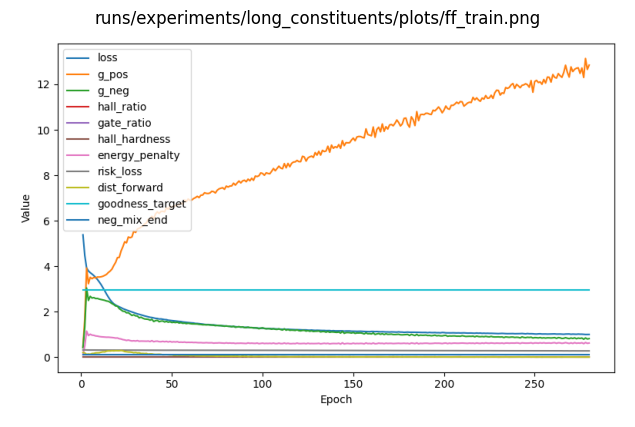

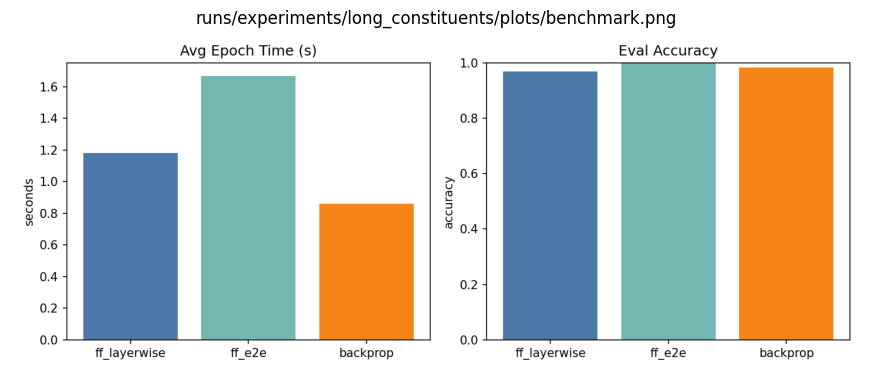

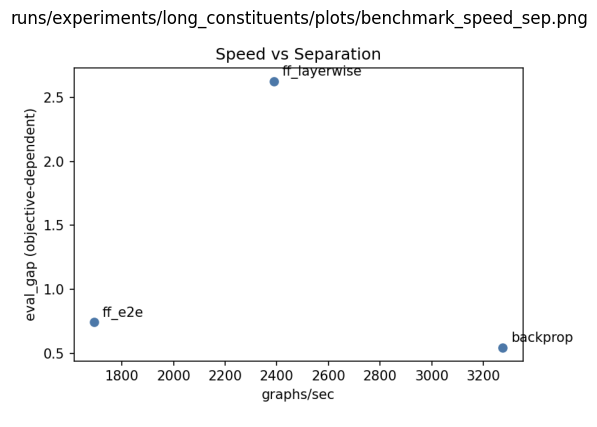

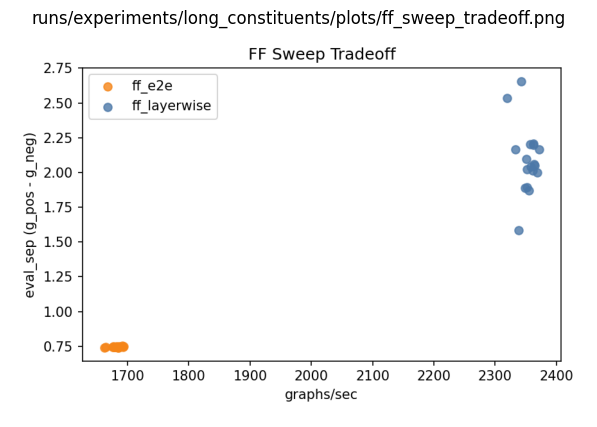

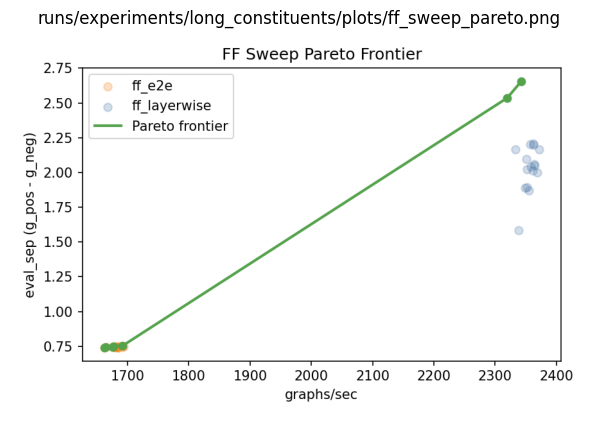

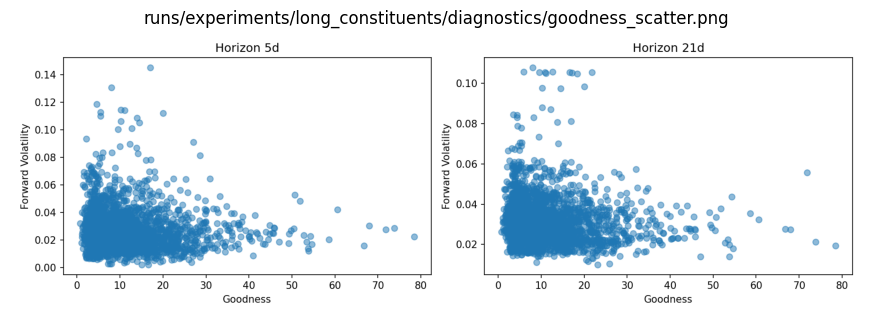

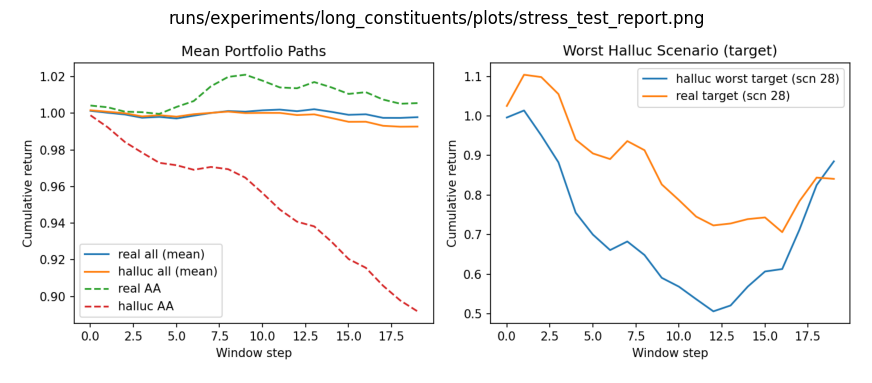

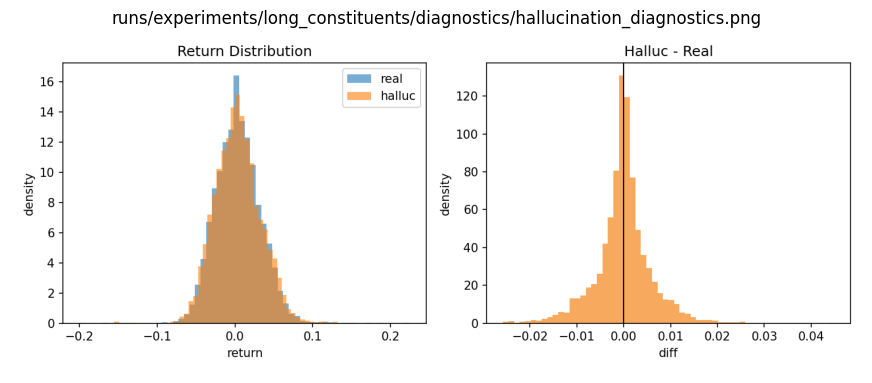

In [17]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

images = [
    f'{RUN_ROOT}/plots/ff_train.png',
    f'{RUN_ROOT}/plots/benchmark.png',
    f'{RUN_ROOT}/plots/benchmark_speed_sep.png',
    SWEEP_TRADEOFF_PNG,
    SWEEP_PARETO_PNG,
    GOODNESS_SCATTER_PNG,
    STRESS_PLOT,
    HALL_DIAG_PNG,
]

for img_path in images:
    p = Path(img_path)
    if not p.exists():
        continue
    img = Image.open(p)
    plt.figure(figsize=(11, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(str(p))
    plt.show()



## 9) Download Artifact Bundle


In [18]:
from pathlib import Path

bundle = Path(ARTIFACT_BUNDLE)
if bundle.exists():
    print('bundle:', bundle, 'size_mb=', round(bundle.stat().st_size / (1024 * 1024), 2))
    try:
        from google.colab import files
        files.download(str(bundle))
    except Exception as exc:
        print('Auto-download unavailable in this runtime:', exc)
else:
    print('Artifact bundle not found:', bundle)


bundle: runs/experiments/long_constituents/bundles/colab_intensive_bundle.zip size_mb= 15.48


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes

- This notebook is configured for a heavy Colab T4 session; long cells can run for hours.
- `RUN_PROMOTE_SWEEP=True` mutates `TRAIN_CONFIG` with promoted parameters.
- If CUDA OOM occurs, reduce batch size in `TRAIN_CONFIG` and rerun from training onward.
- Keep runtime connected during intensive runs to avoid kernel reset.
- Sweep promotion in `auto` mode now uses objective-aware rank (`rank_value`) when available.
